## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

# For preprocessing and modeling
import ast
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer, LabelEncoder
from typing import Tuple
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## load and explore data

In [ ]:
def load_and_explore_data(file_path='bank_transactions.csv'):
    """Load the data from CSV file and perform initial exploration"""
    print(f"\n--- Loading data from {file_path} ---")
    
    # Load the data
    try:
        df = pd.read_csv(file_path, on_bad_lines='warn', delimiter=',',encoding='cp1252') 
        print(f"Data loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")
    except FileNotFoundError:
        print(f"File {file_path} not found. Please check the file path.")
        return None
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
    # Display basic information
    print("\nFirst 5 rows of the data:")
    print(df.head())
    
    print("\nData information:")
    print(df.info())
    
    print("\nSummary statistics:")
    print(df.describe())
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print("\nMissing values in each column:")
    print(missing_values)
    
    return df

### NOTE: I found a big problem in Data with (OwnedProducts) column values. i found them separated in many columns not only in this column so i add these columns in the csv and i will concatenate them in the notebook to cover this column problem.

In [17]:
df = load_and_explore_data('/kaggle/input/transactions/bank_customer_transactions.csv')


--- Loading data from /kaggle/input/transactions/bank_customer_transactions.csv ---
Data loaded successfully with 1048567 rows and 16 columns

First 5 rows of the data:
  TransactionID CustomerID         CustomerDOB CustGender CustLocation  \
0            T1   C5841053  1994+AC0-01+AC0-10          F   JAMSHEDPUR   
1            T2   C2142763  2057+AC0-04+AC0-04          M      JHAJJAR   
2            T3   C4417068  1996+AC0-11+AC0-26          F       MUMBAI   
3            T4   C5342380  2073+AC0-09+AC0-14          F       MUMBAI   
4            T5   C9031234  1988+AC0-03+AC0-24          F  NAVI MUMBAI   

  CustAccountBalance TransactionDate TransactionTime  TransactionAmount (INR)  \
0           17819.05        2/8/2016          143207                     25.0   
1            2270.69        2/8/2016          141858                  27999.0   
2           17874.44        2/8/2016          142712                    459.0   
3          866503.21        2/8/2016          142714         

In [18]:
df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts,Add1,Add2,Add3,Add4,Add5,Unnamed: 15
0,T1,C5841053,1994+AC0-01+AC0-10,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0,#NAME?,loans,savings+ACI-,NaN,NaN,NaN,NaN
1,T2,C2142763,2057+AC0-04+AC0-04,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0,tds,NaN,NaN,NaN,NaN,NaN,NaN
2,T3,C4417068,1996+AC0-11+AC0-26,F,MUMBAI,17874.44,2/8/2016,142712,459.0,#NAME?,savings+ACI-,NaN,NaN,NaN,NaN,NaN
3,T4,C5342380,2073+AC0-09+AC0-14,F,MUMBAI,866503.21,2/8/2016,142714,2060.0,#NAME?,savings+ACI-,NaN,NaN,NaN,NaN,NaN
4,T5,C9031234,1988+AC0-03+AC0-24,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5,#NAME?,savings+ACI-,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990+AC0-04+AC0-08,M,NEW DELHI,7635.19,18/9/16,184824,799.0,#NAME?,savings+ACI-,NaN,NaN,NaN,NaN,NaN
1048563,T1048564,C6459278,1992+AC0-02+AC0-20,M,NASHIK,27311.42,18/9/16,183734,460.0,#NAME?,loans,savings+ACI-,NaN,NaN,NaN,NaN
1048564,T1048565,C6412354,1989+AC0-05+AC0-18,M,HYDERABAD,221757.06,18/9/16,183313,770.0,#NAME?,credit card,retirement plan,savings,tds+ACI-,NaN,NaN
1048565,T1048566,C6420483,1978+AC0-08+AC0-30,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0,#NAME?,loans,savings+ACI-,NaN,NaN,NaN,NaN


In [19]:
df['OwnedProducts'] = df[['OwnedProducts', 'Add1','Add2','Add3','Add4','Add5', 'Unnamed: 15']].astype(str).apply(lambda row: ','.join([val for val in row if val and val.lower() != 'nan']), axis=1)


In [20]:
df.drop(columns=['Add1','Add2','Add3','Add4','Add5', 'Unnamed: 15'], inplace=True)

In [21]:
df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts
0,T1,C5841053,1994+AC0-01+AC0-10,F,JAMSHEDPUR,17819.05,2/8/2016,143207,25.0,"#NAME?, loans, savings+ACI-"
1,T2,C2142763,2057+AC0-04+AC0-04,M,JHAJJAR,2270.69,2/8/2016,141858,27999.0,tds
2,T3,C4417068,1996+AC0-11+AC0-26,F,MUMBAI,17874.44,2/8/2016,142712,459.0,"#NAME?, savings+ACI-"
3,T4,C5342380,2073+AC0-09+AC0-14,F,MUMBAI,866503.21,2/8/2016,142714,2060.0,"#NAME?, savings+ACI-"
4,T5,C9031234,1988+AC0-03+AC0-24,F,NAVI MUMBAI,6714.43,2/8/2016,181156,1762.5,"#NAME?, savings+ACI-"
...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990+AC0-04+AC0-08,M,NEW DELHI,7635.19,18/9/16,184824,799.0,"#NAME?, savings+ACI-"
1048563,T1048564,C6459278,1992+AC0-02+AC0-20,M,NASHIK,27311.42,18/9/16,183734,460.0,"#NAME?, loans, savings+ACI-"
1048564,T1048565,C6412354,1989+AC0-05+AC0-18,M,HYDERABAD,221757.06,18/9/16,183313,770.0,"#NAME?, credit card, retirement plan, savings,..."
1048565,T1048566,C6420483,1978+AC0-08+AC0-30,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0,"#NAME?, loans, savings+ACI-"


In [22]:
mydf = df.copy()

In [23]:
def parse_transaction_date(x):
    try:
        return pd.to_datetime(x, dayfirst=True, errors='coerce')
    except:
        try:
            return datetime.strptime(x, "%d/%m/%y")  # handles 2-digit years
        except:
            return pd.NaT

In [24]:
def clean_owned_products(val):
    if pd.isnull(val) or not isinstance(val, str):
        return []

    # Fix common encoding artifacts
    val = val.replace('+ACI-', '"') \
             .replace('+AC0-', '-') \
             .replace('+ACo-', '*') \
             .replace('+AF8-', '_') \
             .replace('+ACU-', '%') \
             .replace('+ADs-', ';') \
             .replace('+AD0-', '=') \
             .replace('+ACM-', '#') \
             .replace('+AFs-', '[') \
             .replace('+AF0-', ']')

    # Remove any remaining garbage characters (like control codes)
    val = re.sub(r'[^\x20-\x7E]+', '', val)

    # Split, strip, lowercase
    items = [item.strip().lower() for item in val.split(',')]

    # Filter out junk entries
    invalid_values = {'#name?', 'nan', '', 'null'}
    cleaned = [item for item in items if item not in invalid_values]

    return cleaned

## validate and clean data

In [ ]:
def validate_and_clean_data(df):
    """Validate and clean the data"""
    print("\n--- Data Validation and Cleaning ---")
    
    # Make a copy to avoid modifying the original data
    cleaned_df = df.copy()
    
    # Convert dates to datetime
    try:
        cleaned_df['CustomerDOB'] = cleaned_df['CustomerDOB'].astype(str).str.replace('+AC0-', '-', regex=False)
        cleaned_df['CustomerDOB'] = cleaned_df['CustomerDOB'].apply(parse_transaction_date)
        cleaned_df['TransactionDate'] = cleaned_df['TransactionDate'].apply(parse_transaction_date)
    except KeyError as e:
        print(f"Column not found: {e}. Please check the column names in your data.")
    
    # Check for missing values after date conversion
    missing_after_conversion = cleaned_df.isnull().sum()
    print("\nMissing values after date conversion:")
    print(missing_after_conversion[missing_after_conversion > 0])

    
    # Ensure dates are in datetime format and coerce invalid entries to NaT
    date_cols = ['CustomerDOB', 'TransactionDate']
    for col in date_cols:
        if col in cleaned_df.columns:
            cleaned_df[col] = pd.to_datetime(cleaned_df[col], errors='coerce')
    
    # Count missing before dropping
    missing_counts = cleaned_df[date_cols].isnull().sum()
    total_missing = missing_counts.sum()
    
    # Drop rows where either date is missing
    cleaned_df.dropna(subset=date_cols, inplace=True)
    
    # Print summary
    print(f"Dropped {total_missing} rows due to missing or invalid dates:")
    for col in date_cols:
        print(f"  - {col}: {missing_counts[col]} missing")

    
    # Check for outliers in numerical columns
    cleaned_df['CustAccountBalance'] = pd.to_numeric(cleaned_df['CustAccountBalance'], errors='coerce')
    numerical_cols = ['CustAccountBalance', 'TransactionAmount']
    for col in numerical_cols:
        if col in cleaned_df.columns:
            q1 = cleaned_df[col].quantile(0.25)
            q3 = cleaned_df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            outliers = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)]
            print(f"\nOutliers in {col}: {len(outliers)} ({len(outliers)/len(cleaned_df)*100:.2f}%)")
            
            # Cap outliers instead of removing them to preserve customer information
            cleaned_df[col] = cleaned_df[col].clip(lower=lower_bound, upper=upper_bound)
    
    # Convert Unix timestamp to datetime if needed
    if 'TransactionTime' in cleaned_df.columns:
        if isinstance(cleaned_df['TransactionTime'].iloc[0], (int, float)):
            cleaned_df['datetime'] = pd.to_datetime(cleaned_df['TransactionTime'], unit='s')
        else:
            # Try parsing as datetime string
            try:
                cleaned_df['datetime'] = pd.to_datetime(cleaned_df['TransactionTime'])
            except:
                print("Could not convert TransactionTime to datetime. Check the format.")
                
        # Extract time features
        if 'datetime' in cleaned_df.columns:
            cleaned_df['hour'] = cleaned_df['datetime'].dt.hour
            cleaned_df['day_of_week'] = cleaned_df['datetime'].dt.dayofweek
            cleaned_df['is_weekend'] = cleaned_df['day_of_week'].isin([5, 6]).astype(int)
    
    # Check and clean gender values
    if 'CustGender' in cleaned_df.columns:
        # Get unique values
        gender_values = cleaned_df['CustGender'].unique()
        print(f"\nUnique gender values: {gender_values}")
        
        # Standardize gender values
        gender_mapping = {
            'm': 'M', 'male': 'M', 'Male': 'M', 'MALE': 'M',
            'f': 'F', 'female': 'F', 'Female': 'F', 'FEMALE': 'F'
        }
        
        cleaned_df['CustGender'] = cleaned_df['CustGender'].map(
            lambda x: gender_mapping.get(str(x).lower(), x) if pd.notnull(x) else x
        )
        
        # Check again after mapping
        print(f"Gender values after cleaning: {cleaned_df['CustGender'].unique()}")
    
    # Handle OwnedProducts column if it exists
    if 'OwnedProducts' in cleaned_df.columns:
        cleaned_df['OwnedProducts'] = cleaned_df['OwnedProducts'].apply(clean_owned_products)
        
    # Ensure numeric columns are actually numeric
    for col in numerical_cols:
        if col in cleaned_df.columns:
            cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors='coerce')
    
    # Drop rows with all missing values
    cleaned_df = cleaned_df.dropna(how='all')
    
    # Fill remaining missing values
    for col in cleaned_df.columns:
        if cleaned_df[col].isnull().sum() > 0:
            if cleaned_df[col].dtype.kind in 'ifc':  # integer, float, complex
                # Fill missing numeric values with median
                cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())
            else:
                # Fill missing categorical values with mode
                cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].mode()[0])
    
    print(f"\nCleaning completed. Final dataset shape: {cleaned_df.shape}")
    
    return cleaned_df

In [26]:
cleaned_df = validate_and_clean_data(df)


--- Data Validation and Cleaning ---

Missing values after date conversion:
CustomerDOB           3397
CustGender            1100
CustLocation           151
CustAccountBalance    2369
TransactionDate        433
dtype: int64
Dropped 3830 rows due to missing or invalid dates:
  - CustomerDOB: 3397 missing
  - TransactionDate: 433 missing

Outliers in CustAccountBalance: 140278 (13.43%)
Could not convert TransactionTime to datetime. Check the format.

Unique gender values: ['F' 'M' nan 'T']
Gender values after cleaning: ['F' 'M' nan 'T']

Cleaning completed. Final dataset shape: (1044737, 10)


In [27]:
cleaned_df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,"[loans, savings""]"
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,[tds]
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,"[savings""]"
3,T4,C5342380,2073-09-14,F,MUMBAI,136435.61,2016-08-02,142714,2060.0,"[savings""]"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,"[savings""]"
...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-08-04,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,"[savings""]"
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,"[loans, savings""]"
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,136435.61,2016-09-18,183313,770.0,"[credit card, retirement plan, savings, tds""]"
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,"[loans, savings""]"


In [28]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1044737 entries, 0 to 1048566
Data columns (total 10 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1044737 non-null  object        
 1   CustomerID               1044737 non-null  object        
 2   CustomerDOB              1044737 non-null  datetime64[ns]
 3   CustGender               1044737 non-null  object        
 4   CustLocation             1044737 non-null  object        
 5   CustAccountBalance       1044737 non-null  float64       
 6   TransactionDate          1044737 non-null  datetime64[ns]
 7   TransactionTime          1044737 non-null  object        
 8   TransactionAmount (INR)  1044737 non-null  float64       
 9   OwnedProducts            1044737 non-null  object        
dtypes: datetime64[ns](2), float64(2), object(6)
memory usage: 87.7+ MB


In [30]:
cleaned_df.to_csv('cleaned_data.csv', index=False, encoding='utf-8')

## Using data after cleaning

In [2]:
data = pd.read_csv(r"D:\iti\Unsupervised ML_2\Project\cleaned_data.csv")
data

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,"['loans', 'savings""']"
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,['tds']
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,"['savings""']"
3,T4,C5342380,2073-09-14,F,MUMBAI,136435.61,2016-08-02,142714,2060.0,"['savings""']"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,"['savings""']"
...,...,...,...,...,...,...,...,...,...,...
1044732,T1048563,C8020229,1990-08-04,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,"['savings""']"
1044733,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,"['loans', 'savings""']"
1044734,T1048565,C6412354,1989-05-18,M,HYDERABAD,136435.61,2016-09-18,183313,770.0,"['credit card', 'retirement plan', 'savings', ..."
1044735,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,"['loans', 'savings""']"


In [3]:
data['OwnedProducts']

0                                      ['loans', 'savings"']
1                                                    ['tds']
2                                               ['savings"']
3                                               ['savings"']
4                                               ['savings"']
                                 ...                        
1044732                                         ['savings"']
1044733                                ['loans', 'savings"']
1044734    ['credit card', 'retirement plan', 'savings', ...
1044735                                ['loans', 'savings"']
1044736       ['credit card', 'retirement plan', 'savings"']
Name: OwnedProducts, Length: 1044737, dtype: object

## features engineering

In [4]:
def clean_and_parse_owned_products(val):
    if pd.isnull(val):
        return []
    try:
        fixed = val.replace('"', "'")  
        return [item.strip().lower() for item in ast.literal_eval(fixed)]
    except (ValueError, SyntaxError):
        return []

In [5]:
def is_meaningful_product(product):
    # Returns False for pure numbers, decimals, and alphanumerics
    return not re.fullmatch(r'[\w\s]*\d+[\w\s]*|^\d*\.?\d+$', str(product).strip(), re.IGNORECASE)


In [6]:
# Find the most frequent CustGender value for each CustomerID
most_frequent_gender = data.groupby('CustomerID')['CustGender'].agg(lambda x: x.mode()[0])

# Map the most frequent gender back to the original dataframe
data['CustGender'] = data['CustomerID'].map(most_frequent_gender)


In [8]:
def engineer_features(df):

    # Create a copy to avoid modifying the original data
    df_with_features = df.copy()

    # Handel Genders 
    df_with_features = df_with_features[df_with_features['CustGender'].isin(['M', 'F'])]

        # Calculate customer age from DOB
    if 'CustomerDOB' in df_with_features.columns:
        df_with_features['CustomerDOB'] = pd.to_datetime(df_with_features['CustomerDOB'], errors='coerce')
        current_year = datetime.now().year
        df_with_features['CustomerAge'] = current_year - df_with_features['CustomerDOB'].dt.year
        df_with_features['CustomerAge'] = df_with_features['CustomerAge'].abs()
        df_with_features = df_with_features[df_with_features['CustomerAge'] <= 120]

    
    # Create time-based features
    if 'TransactionDate' in df_with_features.columns:
        df_with_features['TransactionDate'] = pd.to_datetime(df_with_features['TransactionDate'], errors='coerce')
        df_with_features['TransactionMonth'] = df_with_features['TransactionDate'].dt.month
        df_with_features['TransactionDayOfMonth'] = df_with_features['TransactionDate'].dt.day
        df_with_features['TransactionQuarter'] = df_with_features['TransactionDate'].dt.quarter
        
    # Time of day categories if hour exists
    if 'hour' in df_with_features.columns:
        bins = [0, 6, 12, 18, 24]
        labels = ['Night', 'Morning', 'Afternoon', 'Evening']
        df_with_features['TimeOfDay'] = pd.cut(df_with_features['hour'], bins=bins, labels=labels, include_lowest=True)

    
    # Process product ownership
    if 'OwnedProducts' in df_with_features.columns:
        # Step 1: Clean and parse
        df_with_features['OwnedProducts_clean'] = df_with_features['OwnedProducts'].apply(clean_and_parse_owned_products)
        
        # Step 2: Dynamically extract unique product types
        unique_products = set()
        df_with_features['OwnedProducts_clean'].apply(unique_products.update)
        unique_products = sorted(unique_products)  
        
        # Step 3: Create binary features
        for product in unique_products:
            if not is_meaningful_product(product):
                continue

            product_col = f"Has_{product.replace(' ', '_').capitalize()}"
            df_with_features[product_col] = df_with_features['OwnedProducts_clean'].apply(
                lambda prod_list: int(product in prod_list))
        
        # Step 4: Count number of products
        df_with_features['ProductCount'] = df_with_features['OwnedProducts_clean'].apply(len)
        
        # Clean up
        df_with_features.drop(columns=['OwnedProducts_clean'], inplace=True)

        # Step 5: Apply PCA to reduce Has_* columns to 2 components
        has_columns = [col for col in df_with_features.columns if col.startswith('Has_')]
        if has_columns:
            pca = PCA(n_components=2)
            pca_result = pca.fit_transform(df_with_features[has_columns])
            df_with_features['PCA1'] = pca_result[:, 0]
            df_with_features['PCA2'] = pca_result[:, 1]
            df_with_features.drop(columns=has_columns, inplace=True)


        # Simplify locations using frequency-based encoding
    if 'CustLocation' in df_with_features.columns:
        location_counts = df_with_features['CustLocation'].value_counts(normalize=True)
        df_with_features['CustLocationFrequency'] = df_with_features['CustLocation'].map(location_counts)

  
    # Bin transaction amounts
    if 'TransactionAmount' in df_with_features.columns:
        df_with_features['TransactionSizeCategory'] = pd.qcut(
            df_with_features['TransactionAmount'], 
            q=[0, 0.25, 0.5, 0.75, 1.0], 
            labels=['Small', 'Medium', 'Large', 'Very Large']
        )
    
    # Print new features
    new_cols = set(df_with_features.columns) - set(df.columns)
    print(f"Added {len(new_cols)} new features: {new_cols}")
    
    return df_with_features


In [9]:
df_with_features = engineer_features(data)


Added 8 new features: {'TransactionQuarter', 'CustomerAge', 'CustLocationFrequency', 'PCA2', 'PCA1', 'ProductCount', 'TransactionMonth', 'TransactionDayOfMonth'}


In [10]:
df_with_features

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts,CustomerAge,TransactionMonth,TransactionDayOfMonth,TransactionQuarter,ProductCount,PCA1,PCA2,CustLocationFrequency
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,"['loans', 'savings""']",31,8,2,3,0,-0.217705,-0.118363,0.001571
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,['tds'],32,8,2,3,1,-0.217856,-0.118577,0.000873
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,"['savings""']",29,8,2,3,0,-0.217705,-0.118363,0.099471
3,T4,C5342380,2073-09-14,F,MUMBAI,136435.61,2016-08-02,142714,2060.0,"['savings""']",48,8,2,3,0,-0.217705,-0.118363,0.099471
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,"['savings""']",37,8,2,3,0,-0.217705,-0.118363,0.012154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044732,T1048563,C8020229,1990-08-04,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,"['savings""']",35,9,18,3,0,-0.217705,-0.118363,0.077533
1044733,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,"['loans', 'savings""']",33,9,18,3,0,-0.217705,-0.118363,0.004711
1044734,T1048565,C6412354,1989-05-18,M,HYDERABAD,136435.61,2016-09-18,183313,770.0,"['credit card', 'retirement plan', 'savings', ...",36,9,18,3,0,-0.217705,-0.118363,0.022129
1044735,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,"['loans', 'savings""']",47,9,18,3,0,-0.217705,-0.118363,0.004230


In [11]:
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 987404 entries, 0 to 1044736
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            987404 non-null  object        
 1   CustomerID               987404 non-null  object        
 2   CustomerDOB              987404 non-null  datetime64[ns]
 3   CustGender               987404 non-null  object        
 4   CustLocation             987404 non-null  object        
 5   CustAccountBalance       987404 non-null  float64       
 6   TransactionDate          987404 non-null  datetime64[ns]
 7   TransactionTime          987404 non-null  object        
 8   TransactionAmount (INR)  987404 non-null  float64       
 9   OwnedProducts            987404 non-null  object        
 10  CustomerAge              987404 non-null  int32         
 11  TransactionMonth         987404 non-null  int32         
 12  TransactionDayOfMont

## plot distribution and correlation

In [12]:
def plot_distribution_and_correlation(df):

    # Select only numeric columns
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if not num_cols:
        print("No numeric columns found in the dataframe.")
        return
    
    # Plot distribution of numerical columns
    plt.figure(figsize=(20, 10))
    for i, col in enumerate(num_cols):
        plt.subplot(2, (len(num_cols) + 1) // 2, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Plot pairwise correlation
    if len(num_cols) > 1:  # Correlation requires at least two numeric columns
        plt.figure(figsize=(12, 8))
        corr = df[num_cols].corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
        plt.title('Pairwise Correlation')
        plt.show()
    else:
        print("Not enough numeric columns for correlation plot.")


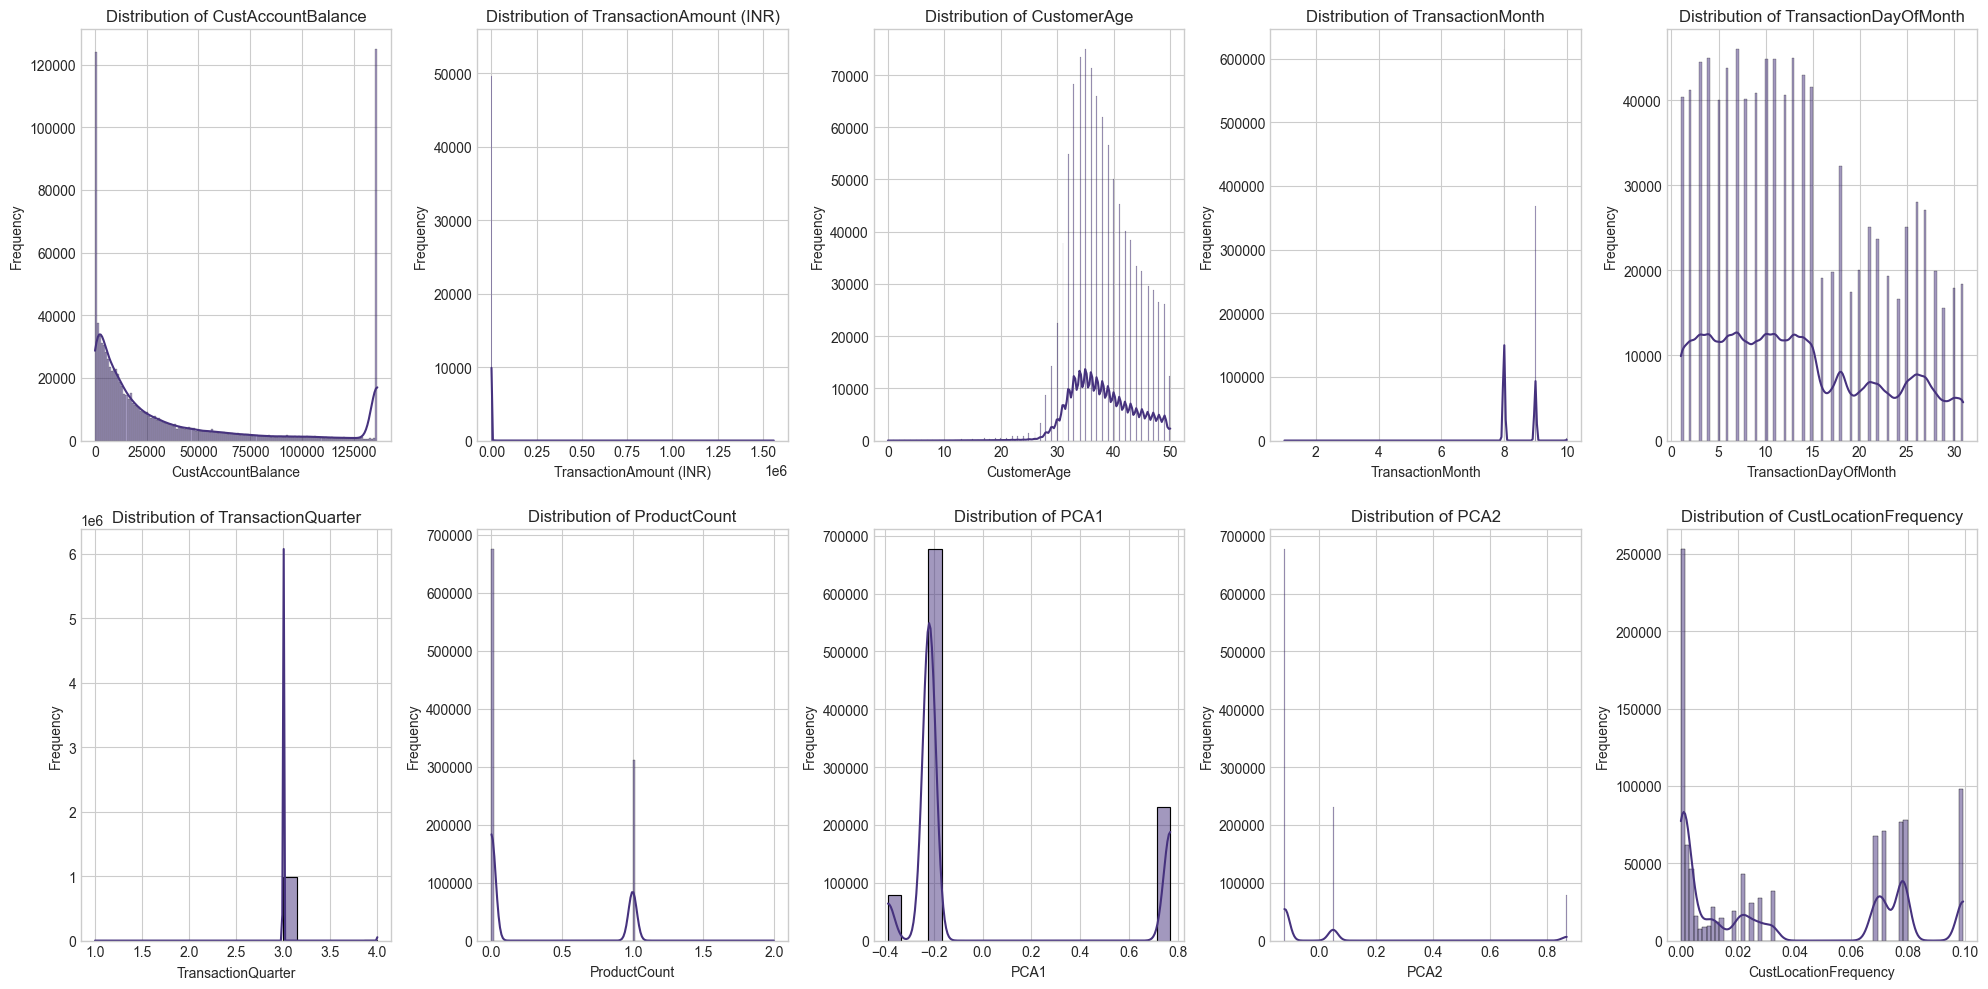

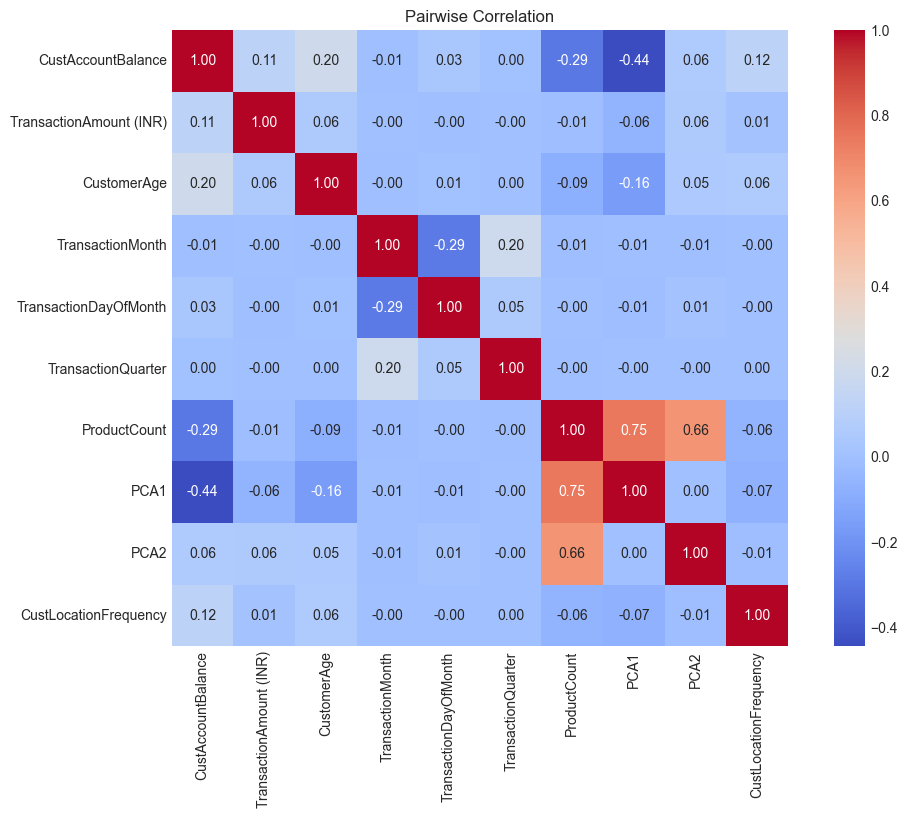

In [13]:
plot_distribution_and_correlation(df_with_features)

## aggregate to customer level

In [14]:
def aggregate_to_customer_level(df):

    # Group by customer ID and aggregate
    agg_df = df.groupby('CustomerID').agg({
        'CustAccountBalance': ['mean', 'median', 'first', 'last', lambda x: np.log1p(x.mean())],
        'TransactionAmount (INR)': ['mean', 'sum', 'max', 'count', lambda x: np.log1p(x.mean())],
        'PCA1': 'mean',
        'PCA2': 'mean',
        'CustGender': 'first',
        'CustLocationFrequency': ['mean', lambda x: np.log1p(x.mean())],
        'TransactionDate': ['min', 'max'],
        'CustomerAge': 'mean'
    }).reset_index()
    
    # Flatten MultiIndex columns properly
    agg_df.columns = ['_'.join([c for c in col if c]).strip() for col in agg_df.columns.values]
    
    # Rename columns for clarity
    agg_df.rename(columns={
        'CustAccountBalance_mean': 'CustAccountBalance_mean',
        'CustAccountBalance_median': 'CustAccountBalance_median',
        'CustAccountBalance_first': 'CustAccountBalance_first',
        'CustAccountBalance_last': 'CustAccountBalance_last',
        '<lambda_0>': 'CustAccountBalance_log_mean',
        'TransactionAmount (INR)_mean': 'TransactionAmount (INR)_mean',
        'TransactionAmount (INR)_sum': 'TransactionAmount (INR)_sum',
        'TransactionAmount (INR)_max': 'TransactionAmount (INR)_max',
        'TransactionAmount (INR)_count': 'TransactionAmount (INR)_count',
        '<lambda_1>': 'TransactionAmount_log_mean',
        'PCA1_mean': 'pca-1_mean',
        'PCA2_mean': 'pca-2_mean',
        'CustGender_first': 'Gender_F_first',
        'CustLocationFrequency_mean': 'LocationFreq_mean',
        '<lambda_2>': 'LocationFreq_log_mean',
        'TransactionDate_min': 'FullTransactionDatetime_first',
        'TransactionDate_max': 'FullTransactionDatetime_last',
        'CustomerAge_mean': 'Age'
    }, inplace=True)

    # Calculate Recency
    agg_df['Recency'] = (datetime.now() - pd.to_datetime(agg_df['FullTransactionDatetime_last'])).dt.days
    
    print(f"Aggregated DataFrame shape: {agg_df.shape}")
    
    return agg_df

In [15]:
agg_df = aggregate_to_customer_level(df_with_features)


Aggregated DataFrame shape: (840584, 20)


In [16]:
agg_df


,CustomerID,CustAccountBalance_mean,CustAccountBalance_median,CustAccountBalance_first,CustAccountBalance_last,CustAccountBalance_<lambda_0>,TransactionAmount (INR)_mean,TransactionAmount (INR)_sum,TransactionAmount (INR)_max,TransactionAmount (INR)_count,TransactionAmount (INR)_<lambda_0>,pca-1_mean,pca-2_mean,Gender_F_first,LocationFreq_mean,CustLocationFrequency_<lambda_0>,FullTransactionDatetime_first,FullTransactionDatetime_last,Age,Recency
0,C1010011,76340.635,76340.635,32500.73,120180.54,11.242974,2553.0,5106.0,4750.0,2,7.845416,-0.217705,-0.118363,F,0.054845,0.053394,2016-08-09,2016-09-26,37.5,3141
1,C1010012,24204.490,24204.490,24204.49,24204.49,10.094335,1499.0,1499.0,1499.0,1,7.313220,-0.217705,-0.118363,M,0.099471,0.094829,2016-08-14,2016-08-14,31.0,3184
2,C1010014,87406.375,87406.375,38377.14,136435.61,11.378335,727.5,1455.0,1205.0,2,6.590988,-0.217705,-0.118363,F,0.099471,0.094829,2016-08-01,2016-08-07,37.0,3191
3,C1010018,496.180,496.180,496.18,496.18,6.208952,30.0,30.0,30.0,1,3.433987,0.767911,0.050630,F,0.000079,0.000079,2016-09-15,2016-09-15,35.0,3152
4,C1010024,87058.650,87058.650,87058.65,87058.65,11.374349,5000.0,5000.0,5000.0,1,8.517393,-0.386700,0.867253,M,0.019300,0.019116,2016-08-18,2016-08-18,40.0,3180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840579,C9099836,133067.230,133067.230,133067.23,133067.23,11.798617,691.0,691.0,691.0,1,6.539586,-0.217705,-0.118363,M,0.000733,0.000733,2016-08-07,2016-08-07,35.0,3191
840580,C9099877,96063.460,96063.460,96063.46,96063.46,11.472775,222.0,222.0,222.0,1,5.407172,-0.386700,0.867253,M,0.078828,0.075875,2016-09-15,2016-09-15,29.0,3152
840581,C9099919,5559.750,5559.750,5559.75,5559.75,8.623488,126.0,126.0,126.0,1,4.844187,-0.217705,-0.118363,M,0.002865,0.002861,2016-08-18,2016-08-18,32.0,3180
840582,C9099941,35295.920,35295.920,35295.92,35295.92,10.471551,50.0,50.0,50.0,1,3.931826,-0.217705,-0.118363,M,0.027926,0.027543,2016-08-28,2016-08-28,30.0,3170


## preprocess for clustering

In [17]:
def preprocess_for_clustering(agg_df: pd.DataFrame) -> Tuple[np.ndarray, PowerTransformer, pd.DataFrame]:
    
    df = agg_df.copy()

    # Step 1: Encode 'Gender_F_first' ('F'/'M') as 0/1
    if 'Gender_F_first' in df.columns:
        print("Encoding Gender_F_first column...")
        gender_encoder = LabelEncoder()
        df['Gender_F_first'] = gender_encoder.fit_transform(df['Gender_F_first'])

    # Step 2: Drop irrelevant columns
    drop_cols = ['CustomerID', 'FullTransactionDatetime_first', 'FullTransactionDatetime_last']
    features_df = df.drop(columns=drop_cols, errors='ignore')

    # Step 3: Drop non-numeric if any
    non_numeric_cols = features_df.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        print(f"Warning: Dropping non-numeric columns: {non_numeric_cols}")
        features_df = features_df.drop(columns=non_numeric_cols)

    # Step 4: Fill missing values
    features_df = features_df.fillna(0)

    # Step 5: Scale using PowerTransformer
    scaler = PowerTransformer(method='yeo-johnson')
    X_scaled = scaler.fit_transform(features_df)

    print(f"Preprocessing done! Final feature shape: {X_scaled.shape}")

    return X_scaled, scaler, features_df



In [18]:
X_scaled, scaler, features_df = preprocess_for_clustering(agg_df)


Encoding Gender_F_first column...
Preprocessing done! Final feature shape: (840584, 17)


## reduce dimensions for Visualization

In [19]:
def reduce_dimensions_for_viz(scaled_df, save_plots=False):

    # Ensure scaled_df is a DataFrame for compatibility with select_dtypes
    if isinstance(scaled_df, np.ndarray):
        scaled_df = pd.DataFrame(scaled_df)
    
    # Select only numeric columns
    numeric_cols = scaled_df.select_dtypes(include=[np.number])
    print(f"Numeric columns for dimensionality reduction: {numeric_cols.columns.tolist()}")
    if numeric_cols.empty:
        print("No numeric columns found in the DataFrame.")
        return None
    
    # === PCA (on full dataset) ===
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(numeric_cols)
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
    print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")
    
    # Plot PCA
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PCA1', y='PCA2', data=pca_df, alpha=0.7)
    plt.title('PCA: 2D Projection of Customer Features')
    plt.xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.2%})')
    if save_plots:
        plt.savefig('pca_visualization.png')
    plt.show()

    print("Dimensionality reduction completed.")

    return pca_df


Numeric columns for dimensionality reduction: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
PCA explained variance (2 components): 56.82%


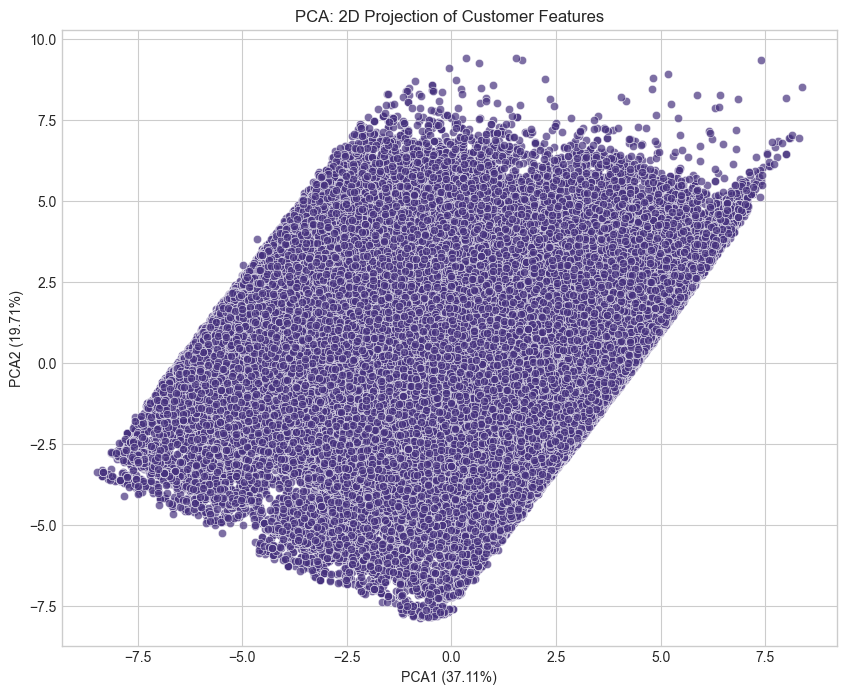

Dimensionality reduction completed.


In [20]:
pca_df = reduce_dimensions_for_viz(X_scaled, save_plots=False)


In [21]:
def apply_elbow_method(scaled_df, max_clusters=10):
    distortions = []
    k_values = range(1, max_clusters + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(scaled_df)
        distortions.append(kmeans.inertia_)
    
    # Plot the elbow curve
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, distortions, marker='o', linestyle='--', color='b')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion (Inertia)')
    plt.xticks(k_values)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    return distortions


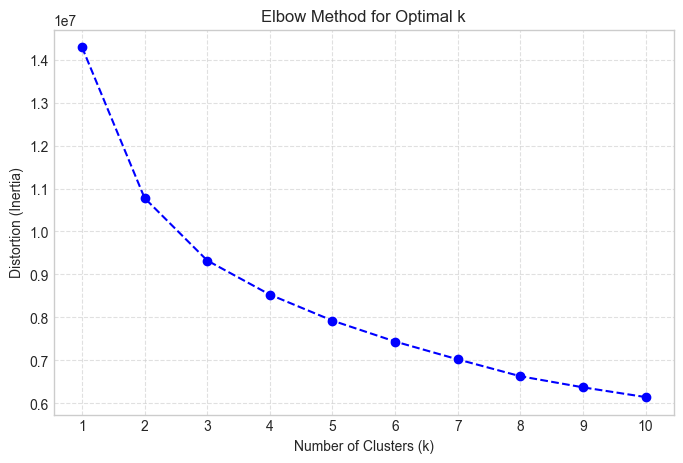

In [22]:
distortions = apply_elbow_method(X_scaled, max_clusters=10)

In [25]:
optimal_k = 3


## perform kmeans clustering

In [26]:
def perform_kmeans_clustering(scaled_df, optimal_k=None):
    
    # Ensure only numeric columns are used
    numeric_cols = scaled_df.select_dtypes(include=[np.number])
    if numeric_cols.empty:
        raise ValueError("No numeric columns found in the DataFrame for clustering.")
    
    # Perform K-means clustering
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(numeric_cols)
    
    # Get cluster centers
    centroids = kmeans.cluster_centers_
    
    # Reduce dimensions using PCA
    pca = PCA(n_components=2)
    pca_features = pca.fit_transform(numeric_cols)
    pca_centroids = pca.transform(centroids)
    
    # Plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        pca_features[:, 0], pca_features[:, 1],
        c=kmeans_labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k'
    )
    
    # Plot centroids
    plt.scatter(
        pca_centroids[:, 0], pca_centroids[:, 1],
        marker='X', s=300, c='red', edgecolors='k', label='Centroid'
    )
    
    # Plot settings
    plt.title(f'K-means Clustering (k={optimal_k}) - PCA Projection', fontsize=16)
    plt.xlabel('Principal Component 1', fontsize=14)
    plt.ylabel('Principal Component 2', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Create a custom legend for clusters
    cluster_labels = [f"Cluster {i}" for i in range(optimal_k)]
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=plt.cm.viridis(i / optimal_k), markersize=10, markeredgecolor='k')
                       for i, label in enumerate(cluster_labels)]
    legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Centroid',
                                  markerfacecolor='red', markersize=12, markeredgecolor='k'))
    
    plt.legend(handles=legend_elements, loc='best', fontsize=12)
    
    # Optional: Annotate centroids
    for idx, (x, y) in enumerate(pca_centroids):
        plt.text(x, y, f'C{idx}', fontsize=10, ha='center', va='center', color='black', fontweight='bold')
    
    plt.show()
    
    print(f"K-means clustering completed with {optimal_k} clusters.")
    
    return kmeans_labels, optimal_k, centroids


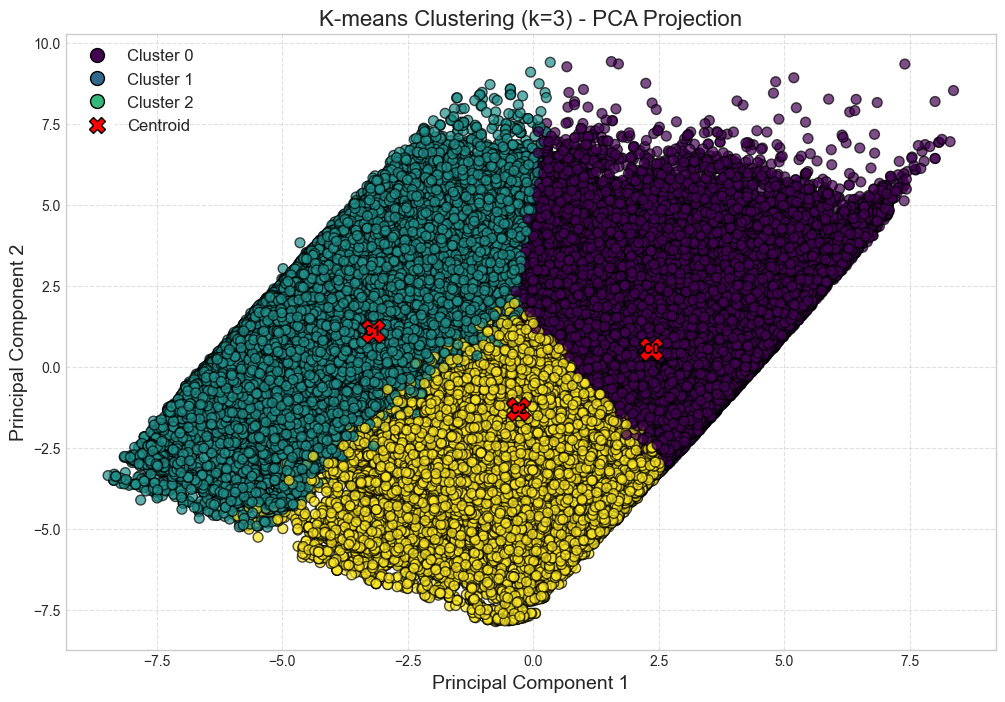

K-means clustering completed with 3 clusters.


In [27]:
kmeans_labels, optimal_k, centroids = perform_kmeans_clustering(pd.DataFrame(X_scaled),optimal_k)

### plot clusters in 3D


In [28]:
def plot_clusters_3d(pca_df, kmeans_labels, centroids):
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot of PCA results
    scatter = ax.scatter(pca_df['PCA1'], pca_df['PCA2'], c=kmeans_labels, cmap='viridis', alpha=0.7)
    
    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1], zs=0, marker='X', s=200, c='red', label='Centroids')
    
    ax.set_title('3D Plot of Clusters')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.set_zlabel('Z-axis (dummy)')
    
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    plt.gca().add_artist(legend1)
    
    plt.show()

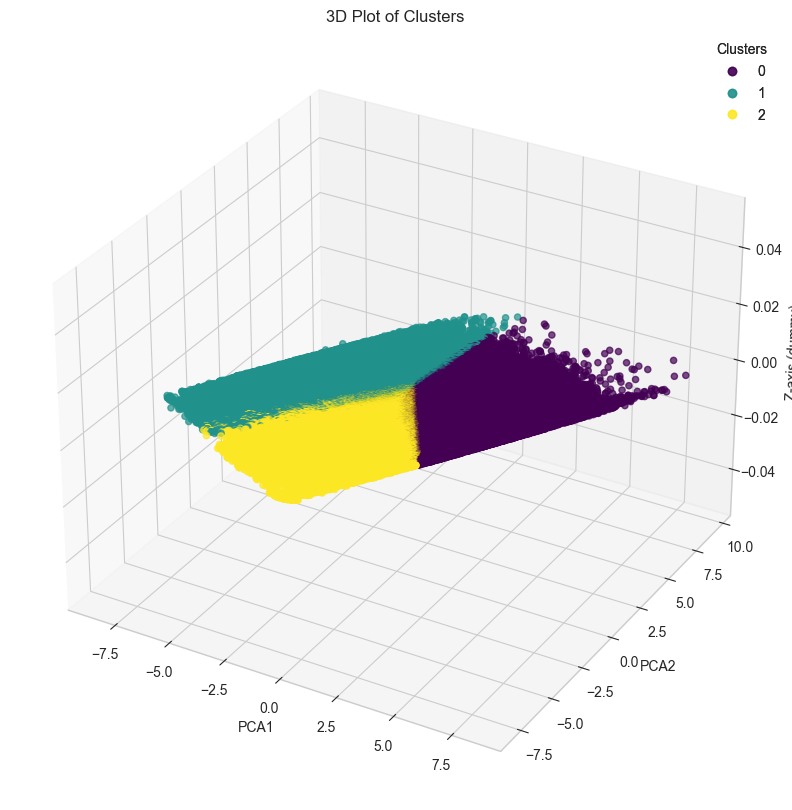

In [27]:
plot_clusters_3d(pca_df, kmeans_labels, centroids)


## perform GMM clustering

In [29]:
def perform_gmm_clustering(scaled_df, optimal_k=None):
    
    # Perform GMM clustering
    gmm = GaussianMixture(n_components=optimal_k, random_state=42)
    gmm_labels = gmm.fit_predict(scaled_df)
    
    # Get cluster centers
    gmm_centroids = gmm.means_
    
    # Reduce dimensions using PCA
    pca = PCA(n_components=2)
    pca_features = pca.fit_transform(scaled_df)
    pca_centroids = pca.transform(gmm_centroids)
    
    # Plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        pca_features[:, 0], pca_features[:, 1],
        c=gmm_labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k'
    )
    
    # Plot centroids
    plt.scatter(
        pca_centroids[:, 0], pca_centroids[:, 1],
        marker='X', s=300, c='red', edgecolors='k', label='Centroid'
    )
    
    # Plot settings
    plt.title(f'GMM Clustering (k={optimal_k}) - PCA Projection', fontsize=16)
    plt.xlabel('Principal Component 1', fontsize=14)
    plt.ylabel('Principal Component 2', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Create a custom legend
    cluster_labels = [f"Cluster {i}" for i in range(optimal_k)]
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=plt.cm.viridis(i / optimal_k), markersize=10, markeredgecolor='k')
                       for i, label in enumerate(cluster_labels)]
    legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Centroid',
                                  markerfacecolor='red', markersize=12, markeredgecolor='k'))
    
    plt.legend(handles=legend_elements, loc='best', fontsize=12)
    
    # Annotate centroids
    for idx, (x, y) in enumerate(pca_centroids):
        plt.text(x, y, f'C{idx}', fontsize=10, ha='center', va='center', color='black', fontweight='bold')
    
    plt.show()
    
    print(f"GMM clustering completed with {optimal_k} clusters.")
    
    return gmm_labels, optimal_k, gmm_centroids


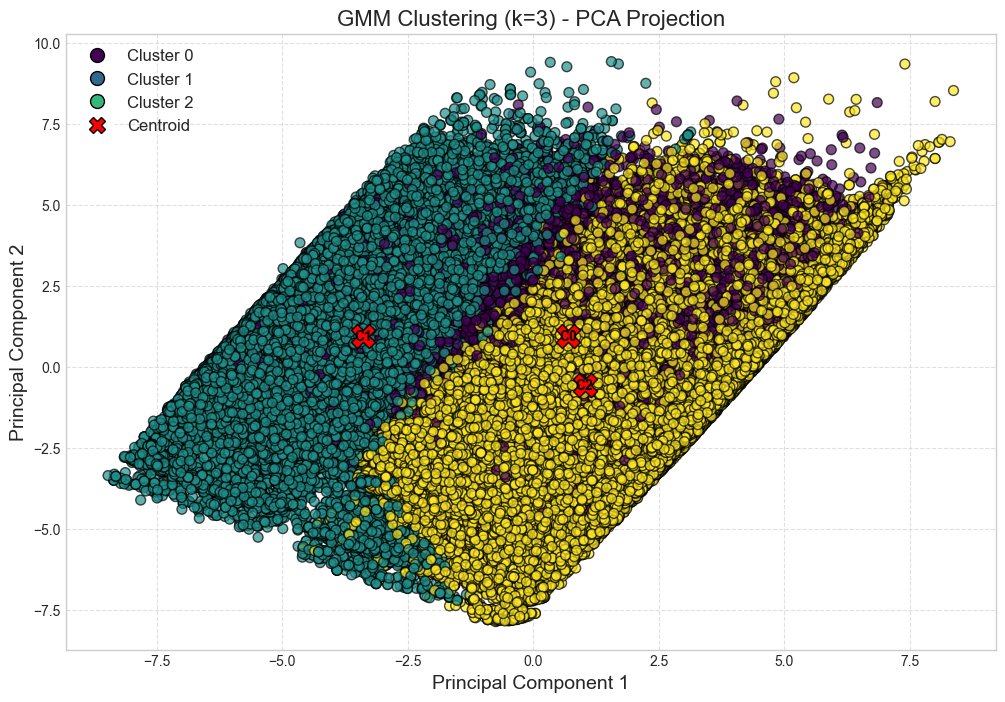

GMM clustering completed with 3 clusters.


In [30]:
gmm_labels, optimal_k, gmm_centroids = perform_gmm_clustering(pd.DataFrame(X_scaled),optimal_k)


### plot clusters in 3D

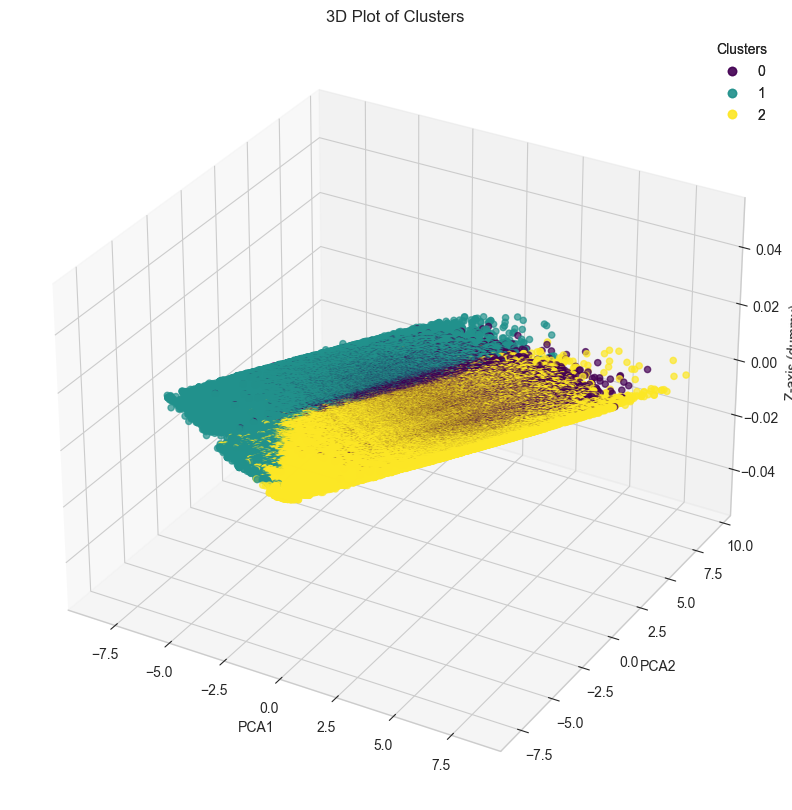

In [31]:
plot_clusters_3d(pca_df, gmm_labels, gmm_centroids)


## analyze clusters

In [32]:
def analyze_clusters(df, labels, cluster_centers=None, feature_names=None, algorithm_name="KMeans"):

    print(f"\n--- {algorithm_name} Cluster Analysis ---")
    
    # Add cluster labels
    df_with_clusters = df.copy()
    df_with_clusters['Cluster'] = labels
    
    # Handle noise points (Cluster -1) if exist
    unique_clusters = sorted(set(labels))
    if -1 in unique_clusters:
        noise_count = (labels == -1).sum()
        print(f"Noise points (Cluster -1): {noise_count} ({noise_count/len(labels):.2%})")
        unique_clusters.remove(-1)
    
    n_clusters = len(unique_clusters)
    print(f"Number of clusters (excluding noise): {n_clusters}")
    
    # Cluster sizes
    cluster_sizes = df_with_clusters['Cluster'].value_counts().sort_index()
    print("\nCluster sizes:")
    print(cluster_sizes)
    
    # Plot cluster sizes
    plt.figure(figsize=(8, 5))
    cluster_sizes.plot(kind='bar', color='skyblue')
    plt.title(f'{algorithm_name} Cluster Sizes')
    plt.xlabel('Cluster Label')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()
    
    # Calculate cluster profiles (mean of numerical features)
    numeric_columns = df_with_clusters.select_dtypes(include=[np.number]).columns.tolist()
    numeric_columns = [col for col in numeric_columns if col != 'Cluster']  
    
    cluster_profiles = df_with_clusters.groupby('Cluster')[numeric_columns].mean()
    print("\nCluster Profiles (Mean of Numerical Features):")
    display(cluster_profiles.style.format(precision=2).background_gradient(axis=1, cmap="Blues"))
    
    # Validate that cluster_centers and feature_names match
    if cluster_centers is not None and feature_names is not None and n_clusters <= 10:
        if cluster_centers.shape[1] != len(feature_names):
            print(f"\nWarning: Mismatch between cluster centers ({cluster_centers.shape[1]}) and feature names ({len(feature_names)}).")
            print("Skipping radar charts.")
        else:
            centers_df = pd.DataFrame(cluster_centers, columns=feature_names)

            # Normalize centers for plotting
            scaler = MinMaxScaler()
            centers_scaled = scaler.fit_transform(centers_df)
            centers_scaled_df = pd.DataFrame(centers_scaled, columns=feature_names)
            
            for i, cluster_idx in enumerate(unique_clusters):
                plt.figure(figsize=(8, 6))

                categories = feature_names
                N = len(categories)
                
                angles = [n / float(N) * 2 * np.pi for n in range(N)]
                angles += angles[:1]
                
                values = centers_scaled_df.iloc[i].tolist()
                values += values[:1]
                
                ax = plt.subplot(111, polar=True)
                ax.plot(angles, values, linewidth=2)
                ax.fill(angles, values, alpha=0.3)
                
                plt.xticks(angles[:-1], categories, fontsize=10)
                ax.set_rlabel_position(30)
                plt.title(f'{algorithm_name} Cluster {cluster_idx} Profile', size=14, y=1.1)
                plt.show()
    
    # Key Features Analysis for each cluster
    print("\nKey Characteristics of Each Cluster:")
    for cluster_idx in unique_clusters:
        cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster_idx]
        other_data = df_with_clusters[df_with_clusters['Cluster'] != cluster_idx]
        
        print(f"\nCluster {cluster_idx} ({len(cluster_data)} customers):")
        
        feature_summary = []
        for feature in numeric_columns:
            cluster_mean = cluster_data[feature].mean()
            others_mean = other_data[feature].mean()
            if pd.isna(cluster_mean) or pd.isna(others_mean):
                continue
            diff = cluster_mean - others_mean
            ratio = cluster_mean / others_mean if others_mean != 0 else np.inf
            feature_summary.append({
                "Feature": feature,
                "ClusterMean": cluster_mean,
                "OtherMean": others_mean,
                "Diff": diff,
                "Ratio": ratio
            })
        
        # Sort features by absolute difference
        feature_summary = pd.DataFrame(feature_summary)
        feature_summary['AbsDiff'] = feature_summary['Diff'].abs()
        top_features = feature_summary.sort_values(by='AbsDiff', ascending=False).head(5)
        
        for _, row in top_features.iterrows():
            if row['Ratio'] > 1:
                print(f"- {row['Feature']}: {row['ClusterMean']:.2f} (vs. {row['OtherMean']:.2f}) --> {row['Ratio']:.1f}x higher")
            else:
                print(f"- {row['Feature']}: {row['ClusterMean']:.2f} (vs. {row['OtherMean']:.2f}) --> {1/row['Ratio']:.1f}x lower")
    
    return df_with_clusters



--- KMeans Cluster Analysis ---
Number of clusters (excluding noise): 3

Cluster sizes:
Cluster
0    323331
1    206764
2    310489
Name: count, dtype: int64


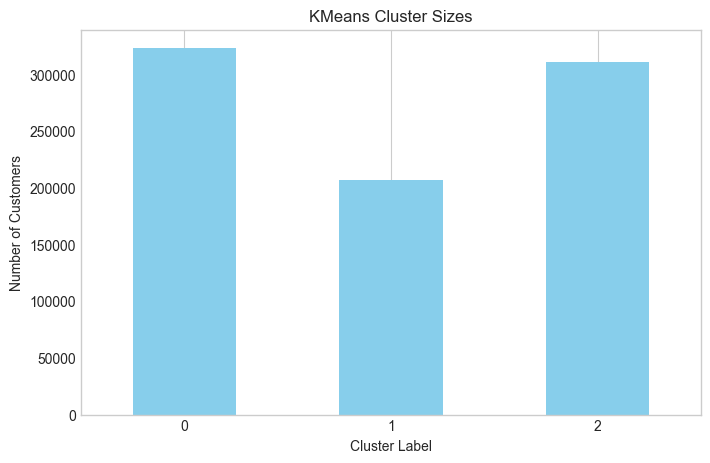


Cluster Profiles (Mean of Numerical Features):


,CustAccountBalance_mean,CustAccountBalance_median,CustAccountBalance_first,CustAccountBalance_last,CustAccountBalance_,TransactionAmount (INR)_mean,TransactionAmount (INR)_sum,TransactionAmount (INR)_max,TransactionAmount (INR)_count,TransactionAmount (INR)_,pca-1_mean,pca-2_mean,LocationFreq_mean,CustLocationFrequency_,Age,Recency
Cluster,,,,,,,,,,,,,,,,
0,69486.13,69176.07,69505.17,69544.72,10.82,3040.64,3621.38,3473.04,1.28,7.29,-0.21,0.03,0.04,0.04,39.73,3168.71
1,2224.32,2135.05,2156.59,2195.50,6.46,740.49,833.96,800.71,1.15,5.55,0.66,0.04,0.03,0.03,36.57,3171.95
2,29061.63,28993.53,29045.25,29065.84,9.83,281.62,300.32,290.62,1.08,5.17,-0.22,-0.06,0.03,0.03,37.16,3172.02


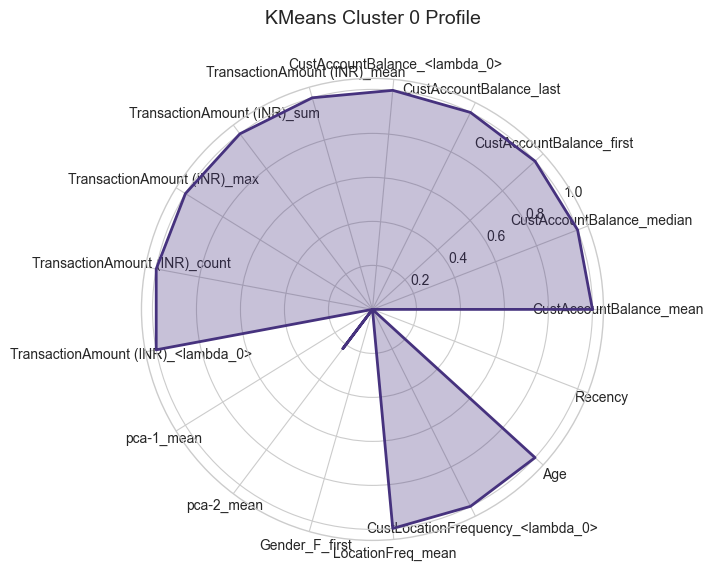

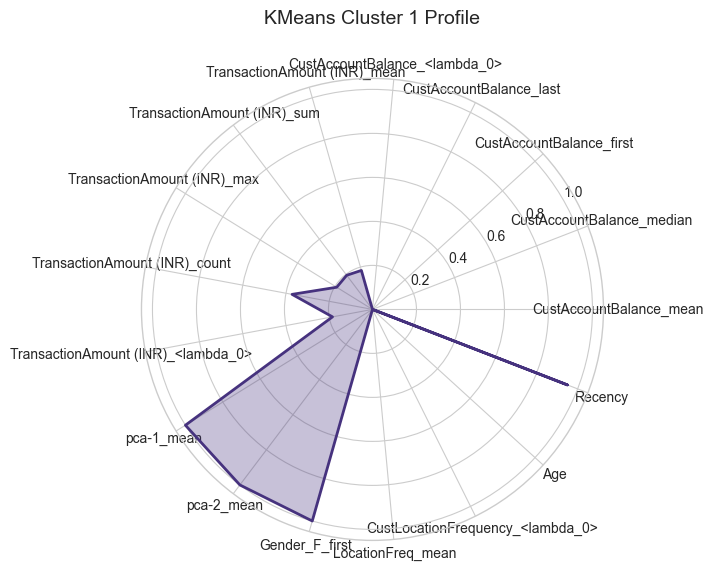

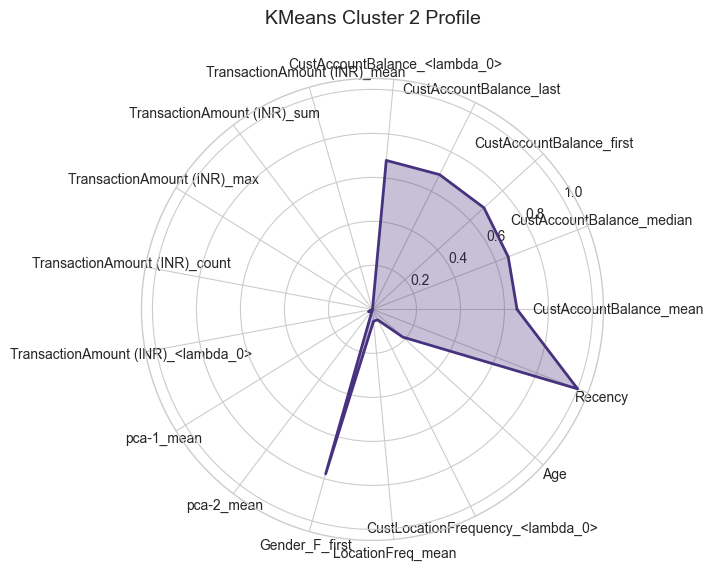


Key Characteristics of Each Cluster:

Cluster 0 (323331 customers):
- CustAccountBalance_last: 69544.72 (vs. 18324.83) --> 3.8x higher
- CustAccountBalance_first: 69505.17 (vs. 18296.92) --> 3.8x higher
- CustAccountBalance_mean: 69486.13 (vs. 18333.82) --> 3.8x higher
- CustAccountBalance_median: 69176.07 (vs. 18257.26) --> 3.8x higher
- TransactionAmount (INR)_sum: 3621.38 (vs. 513.64) --> 7.1x higher

Cluster 1 (206764 customers):
- CustAccountBalance_first: 2156.59 (vs. 49685.10) --> 23.0x lower
- CustAccountBalance_last: 2195.50 (vs. 49715.36) --> 22.6x lower
- CustAccountBalance_mean: 2224.32 (vs. 49683.40) --> 22.3x lower
- CustAccountBalance_median: 2135.05 (vs. 49491.87) --> 23.2x lower
- TransactionAmount (INR)_sum: 833.96 (vs. 1994.49) --> 2.4x lower

Cluster 2 (310489 customers):
- CustAccountBalance_last: 29065.84 (vs. 43275.10) --> 1.5x lower
- CustAccountBalance_first: 29045.25 (vs. 43235.80) --> 1.5x lower
- CustAccountBalance_mean: 29061.63 (vs. 43250.60) --> 1.5x low

In [33]:
kmeans_results = analyze_clusters(
    agg_df, kmeans_labels, centroids, features_df.columns, "KMeans")



--- GMM Cluster Analysis ---
Number of clusters (excluding noise): 3

Cluster sizes:
Cluster
0    129371
1    185226
2    525987
Name: count, dtype: int64


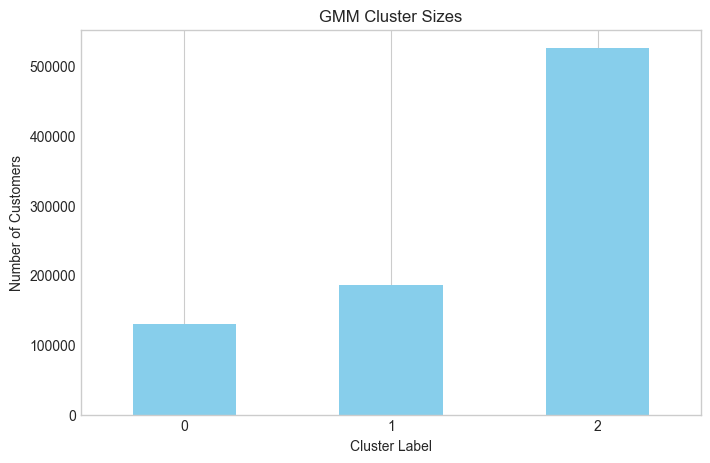


Cluster Profiles (Mean of Numerical Features):


,CustAccountBalance_mean,CustAccountBalance_median,CustAccountBalance_first,CustAccountBalance_last,CustAccountBalance_,TransactionAmount (INR)_mean,TransactionAmount (INR)_sum,TransactionAmount (INR)_max,TransactionAmount (INR)_count,TransactionAmount (INR)_,pca-1_mean,pca-2_mean,LocationFreq_mean,CustLocationFrequency_,Age,Recency
Cluster,,,,,,,,,,,,,,,,
0,38016.89,36935.85,37916.94,38127.38,10.02,1447.93,3093.61,2646.46,2.13,6.47,0.00,0.00,0.04,0.04,37.99,3161.88
1,1759.62,1759.62,1759.62,1759.62,6.24,843.76,843.76,843.76,1.00,5.44,0.67,0.03,0.03,0.03,36.62,3171.31
2,50773.18,50773.18,50773.18,50773.18,10.33,1673.19,1673.19,1673.19,1.00,6.20,-0.24,-0.01,0.04,0.04,38.50,3172.70


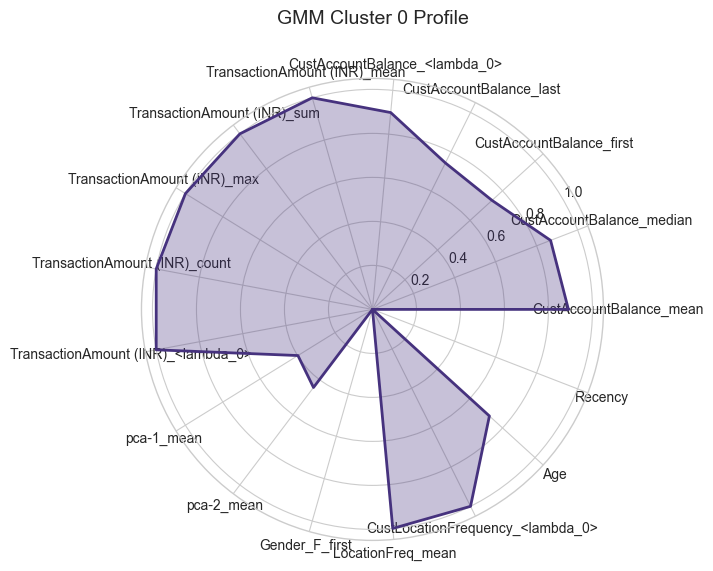

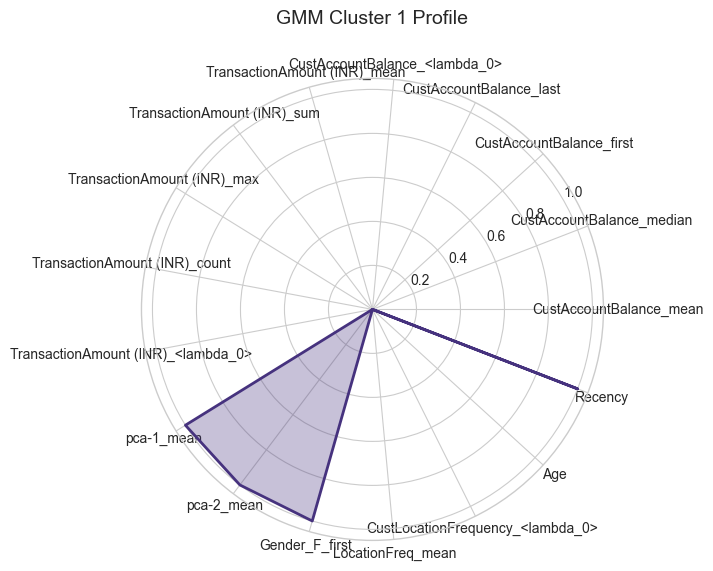

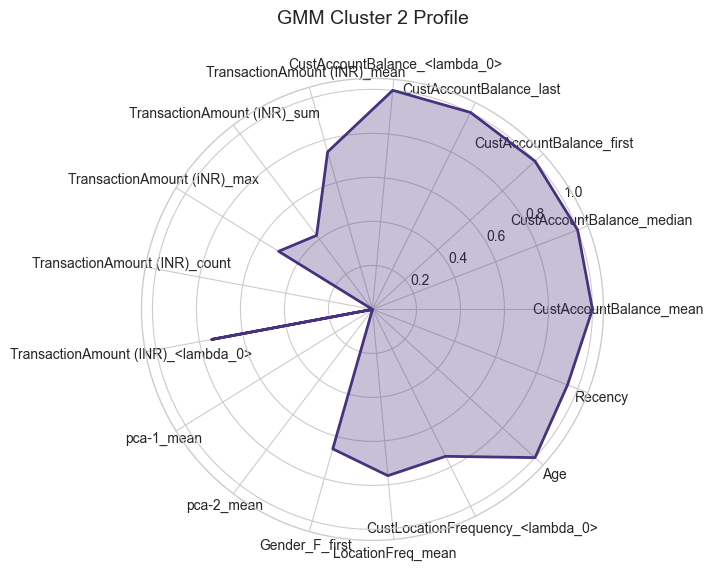


Key Characteristics of Each Cluster:

Cluster 0 (129371 customers):
- TransactionAmount (INR)_sum: 3093.61 (vs. 1457.17) --> 2.1x higher
- TransactionAmount (INR)_max: 2646.46 (vs. 1457.17) --> 1.8x higher
- CustAccountBalance_median: 36935.85 (vs. 38008.25) --> 1.0x lower
- CustAccountBalance_last: 38127.38 (vs. 38008.25) --> 1.0x higher
- CustAccountBalance_first: 37916.94 (vs. 38008.25) --> 1.0x lower

Cluster 1 (185226 customers):
- CustAccountBalance_last: 1759.62 (vs. 48276.84) --> 27.4x lower
- CustAccountBalance_mean: 1759.62 (vs. 48255.02) --> 27.4x lower
- CustAccountBalance_first: 1759.62 (vs. 48235.29) --> 27.4x lower
- CustAccountBalance_median: 1759.62 (vs. 48041.62) --> 27.3x lower
- TransactionAmount (INR)_sum: 843.76 (vs. 1953.59) --> 2.3x lower

Cluster 2 (525987 customers):
- CustAccountBalance_median: 50773.18 (vs. 16225.06) --> 3.1x higher
- CustAccountBalance_first: 50773.18 (vs. 16628.51) --> 3.1x higher
- CustAccountBalance_mean: 50773.18 (vs. 16669.61) --> 3.0

In [34]:
gmm_results = analyze_clusters(
    agg_df, gmm_labels, gmm_centroids, features_df.columns, "GMM")